# Rapport Dataset — Jurida (D1+D2, MMedAgent-Lite Juridique)

**Groupe D1 :** Mohammed Azan, Hashem Emran, Imad  
**Encadrant :** Pr. Abdellatif EL AFIA  

Ce notebook produit les 8 figures + échantillons qualitatifs à partir des parquets stratifiés et du DatasetDict final. La logique métier vit dans `dataset/jur_utils.py`, `dataset/stratify_jur.py` — ici on ne fait que charger et visualiser.

## Pipeline

1. `dataset/download_jur.py` → `data/raw/{qa.csv, documents.csv}` (+ manifest MD5)
2. `dataset/preprocess_jur_fr.py` → `data/interim/qa_fr.parquet`
3. `dataset/preprocess_jur_ar.py` → `data/interim/qa_ar.parquet`
4. `dataset/stratify_jur.py` → scores de difficulté + tertiles + split train/test
5. `dataset/build_hf_dataset.py` → `data/jurida_processed/` (DatasetDict 12 splits)

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from dataset.jur_utils import load_config
from dataset.stratify_jur import compute_features

cfg = load_config(ROOT / 'config.yaml')
FIG_DIR = ROOT / cfg['paths']['figures']
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2', context='paper')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

qa_fr = pd.read_parquet(ROOT / cfg['paths']['interim_fr_qa'])
qa_ar = pd.read_parquet(ROOT / cfg['paths']['interim_ar_qa'])
qa = pd.concat([qa_fr, qa_ar], ignore_index=True)
splits = json.loads((ROOT / cfg['paths']['interim_splits']).read_text(encoding='utf-8'))

print(f'FR Q&A : {len(qa_fr):,} | AR Q&A : {len(qa_ar):,} | Total : {len(qa):,}')
print(f'Seuils difficulté FR : easy≤{splits["fr"]["thresholds"]["easy"]:.3f} medium≤{splits["fr"]["thresholds"]["medium"]:.3f}')
print(f'Seuils difficulté AR : easy≤{splits["ar"]["thresholds"]["easy"]:.3f} medium≤{splits["ar"]["thresholds"]["medium"]:.3f}')

FR Q&A : 13,008 | AR Q&A : 11,932 | Total : 24,940
Seuils difficulté FR : easy≤0.547 medium≤0.677
Seuils difficulté AR : easy≤0.510 medium≤0.637


## Figure 1 — Distribution par langue et type de document

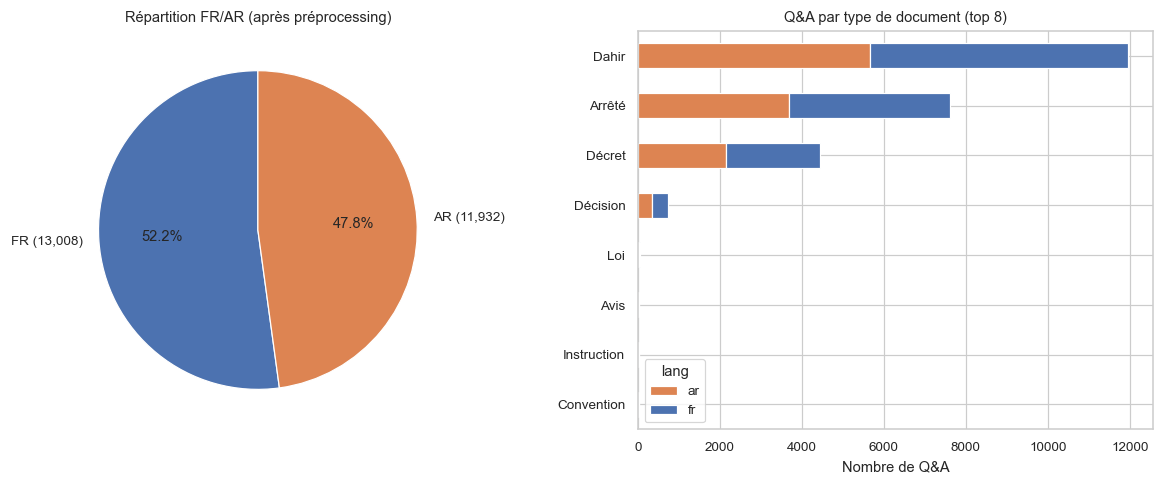

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

lang_counts = qa['lang'].value_counts()
axes[0].pie(lang_counts.values, labels=[f'{l.upper()} ({n:,})' for l, n in lang_counts.items()],
            autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#DD8452'])
axes[0].set_title('Répartition FR/AR (après préprocessing)')

top_types = qa['doc_type'].value_counts().head(8)
lang_by_type = qa.groupby(['doc_type', 'lang']).size().unstack(fill_value=0).loc[top_types.index]
lang_by_type.plot(kind='barh', stacked=True, ax=axes[1], color=['#DD8452', '#4C72B0'])
axes[1].set_title('Q&A par type de document (top 8)')
axes[1].set_xlabel('Nombre de Q&A')
axes[1].set_ylabel('')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_lang_distribution.png')
plt.show()

## Figure 2 — Types de documents (barplot horizontal)

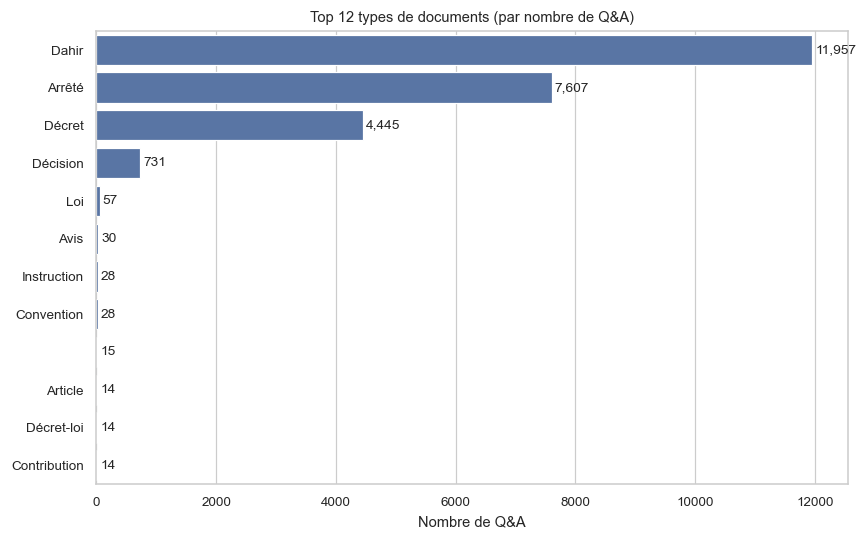

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
doc_type_counts = qa['doc_type'].value_counts().head(12)
sns.barplot(y=doc_type_counts.index, x=doc_type_counts.values, ax=ax, color='#4C72B0')
ax.set_title('Top 12 types de documents (par nombre de Q&A)')
ax.set_xlabel('Nombre de Q&A')
ax.set_ylabel('')
for i, v in enumerate(doc_type_counts.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_doc_types.png')
plt.show()

## Figure 3 — Distribution temporelle

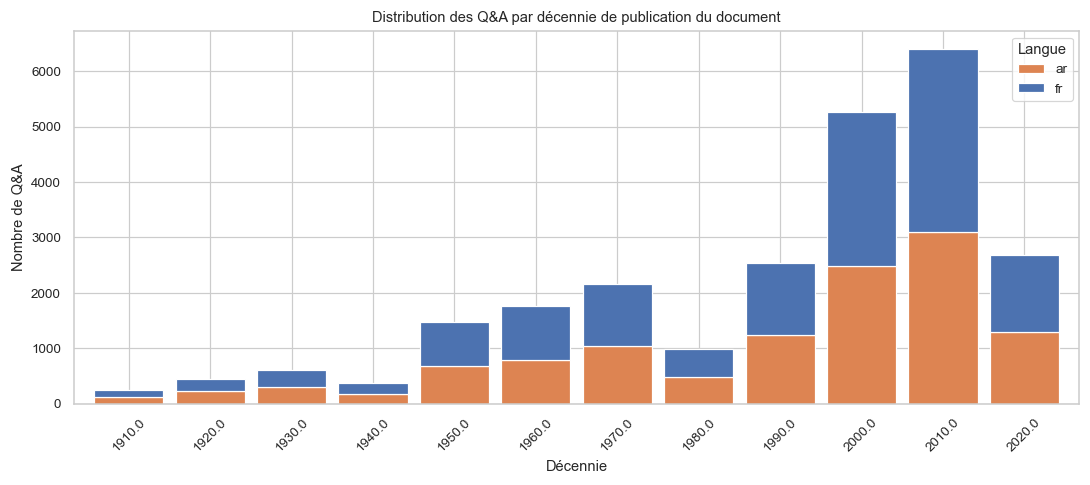

In [4]:
def decade(d):
    if not isinstance(d, str) or len(d) < 4 or not d[:4].isdigit():
        return None
    return int(d[:3]) * 10

tmp = qa.copy()
tmp['decade'] = tmp['doc_date'].map(decade)
tmp = tmp.dropna(subset=['decade'])
tmp = tmp[(tmp['decade'] >= 1900) & (tmp['decade'] <= 2030)]

fig, ax = plt.subplots(figsize=(10, 4.5))
pivot = tmp.groupby(['decade', 'lang']).size().unstack(fill_value=0)
pivot.plot(kind='bar', stacked=True, ax=ax, color=['#DD8452', '#4C72B0'], width=0.85)
ax.set_title('Distribution des Q&A par décennie de publication du document')
ax.set_xlabel('Décennie')
ax.set_ylabel('Nombre de Q&A')
ax.legend(title='Langue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_temporal_distribution.png')
plt.show()

## Figure 4 — Distributions des longueurs en tokens (Qwen2)

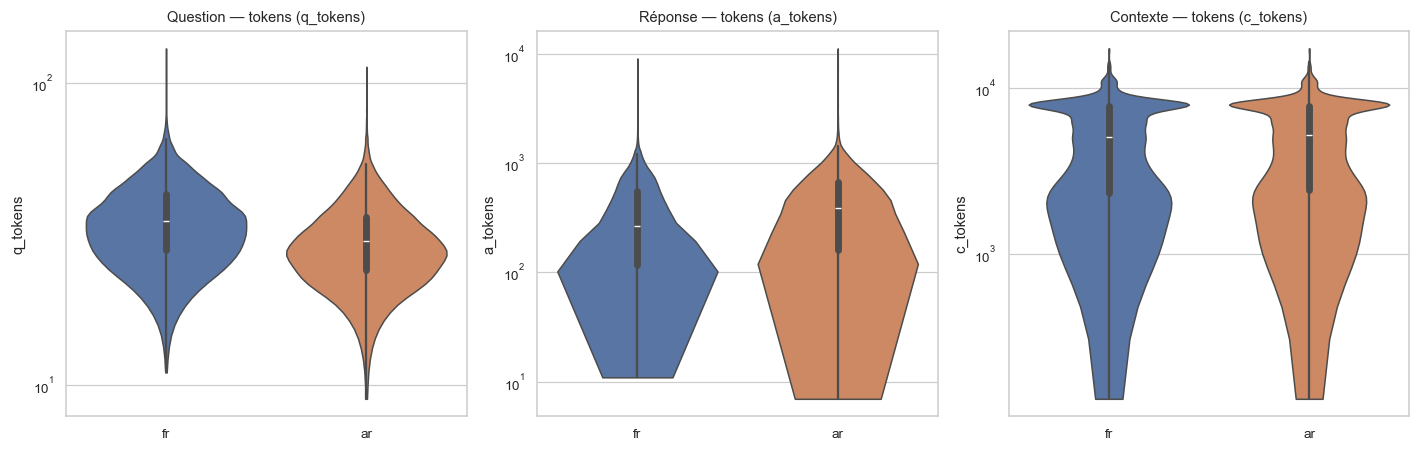

,lang,n,q_med,q_p95,a_med,a_p95,c_med,c_p95,truncated
0,fr,13008,35,55,266,1032,5096,9482,3000
1,ar,11932,30,49,386,1161,5199,9535,2839


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, col, title in zip(axes, ['q_tokens', 'a_tokens', 'c_tokens'],
                           ['Question', 'Réponse', 'Contexte']):
    sns.violinplot(data=qa, x='lang', y=col, ax=ax, hue='lang',
                   palette=['#4C72B0', '#DD8452'], cut=0, legend=False)
    ax.set_yscale('log')
    ax.set_title(f'{title} — tokens ({col})')
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_length_distributions.png')
plt.show()

stats_rows = []
for lang in ('fr', 'ar'):
    sub = qa[qa['lang'] == lang]
    stats_rows.append({
        'lang': lang, 'n': len(sub),
        'q_med': int(sub['q_tokens'].median()), 'q_p95': int(sub['q_tokens'].quantile(0.95)),
        'a_med': int(sub['a_tokens'].median()), 'a_p95': int(sub['a_tokens'].quantile(0.95)),
        'c_med': int(sub['c_tokens'].median()), 'c_p95': int(sub['c_tokens'].quantile(0.95)),
        'truncated': int(sub['truncated'].sum()),
    })
pd.DataFrame(stats_rows)

## Figure 5 — Distribution du score de difficulté avec seuils E/M/H

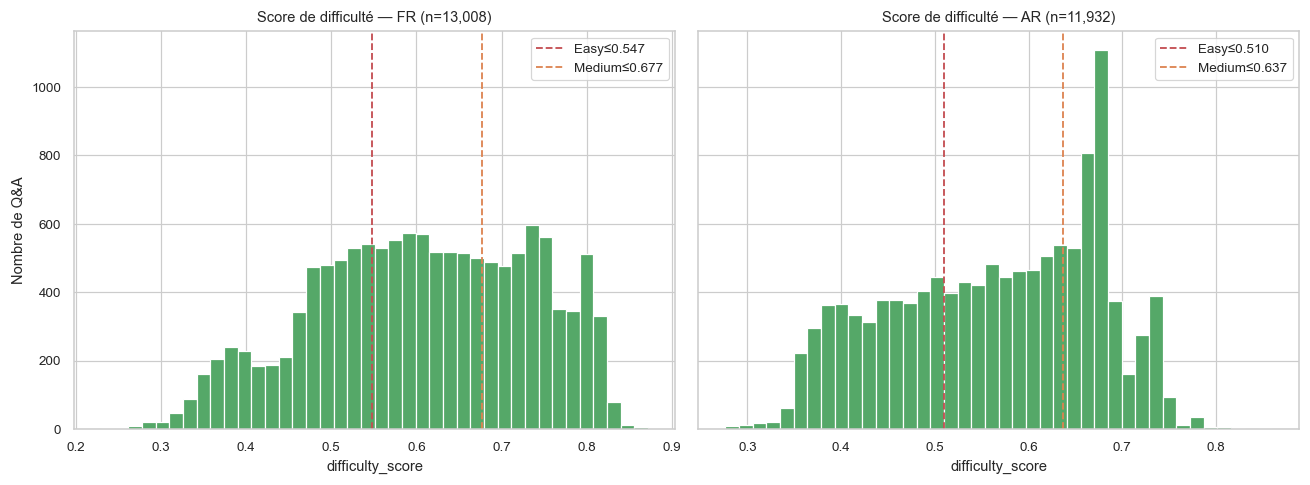

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, lang in zip(axes, ('fr', 'ar')):
    sub = qa[qa['lang'] == lang]
    th = splits[lang]['thresholds']
    ax.hist(sub['difficulty_score'], bins=40, color='#55A868', edgecolor='white')
    ax.axvline(th['easy'], color='#C44E52', linestyle='--', label=f'Easy≤{th["easy"]:.3f}')
    ax.axvline(th['medium'], color='#DD8452', linestyle='--', label=f'Medium≤{th["medium"]:.3f}')
    ax.set_title(f'Score de difficulté — {lang.upper()} (n={len(sub):,})')
    ax.set_xlabel('difficulty_score')
    ax.legend()
axes[0].set_ylabel('Nombre de Q&A')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_difficulty_distribution.png')
plt.show()

## Figure 6 — Heatmap doc_type × difficulté

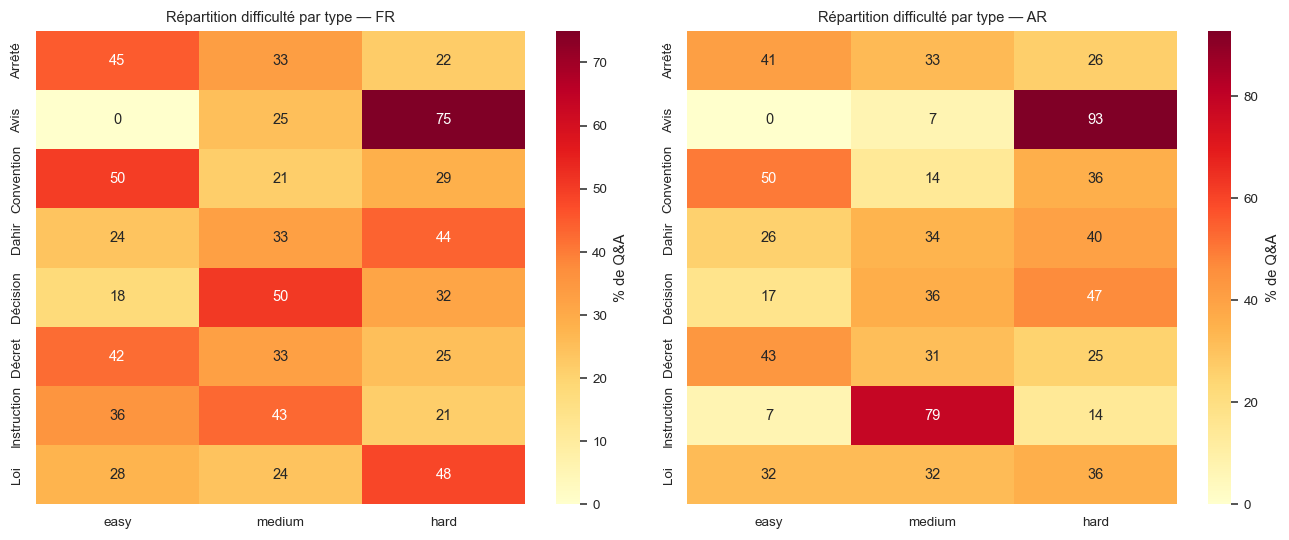

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, lang in zip(axes, ('fr', 'ar')):
    sub = qa[qa['lang'] == lang]
    top_types = sub['doc_type'].value_counts().head(8).index
    mat = sub[sub['doc_type'].isin(top_types)].groupby(['doc_type', 'difficulty']).size().unstack(fill_value=0)
    mat = mat.reindex(columns=['easy', 'medium', 'hard'], fill_value=0)
    mat = mat.div(mat.sum(axis=1), axis=0) * 100
    sns.heatmap(mat, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label': '% de Q&A'})
    ax.set_title(f'Répartition difficulté par type — {lang.upper()}')
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_difficulty_by_doctype.png')
plt.show()

## Figure 7 — Corrélation features f1–f7 vs score composite

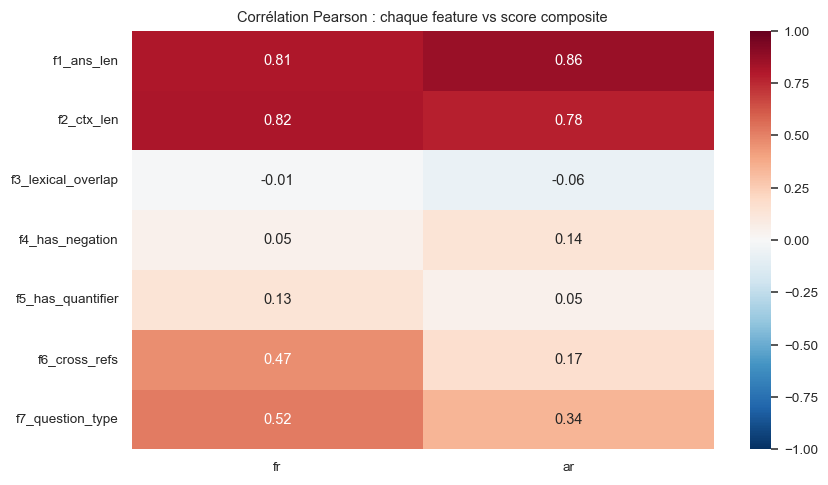

In [8]:
sample = qa.groupby('lang', group_keys=False).sample(n=2000, random_state=42)
feat_rows = []
for lang, sub in sample.groupby('lang'):
    f = compute_features(sub, lang)
    f['score'] = sub['difficulty_score'].values
    f['lang'] = lang
    feat_rows.append(f)
features = pd.concat(feat_rows, ignore_index=True)

feat_cols = [c for c in features.columns if c.startswith('f')]
corrs = {lang: features[features['lang']==lang][feat_cols + ['score']].corr()['score'].drop('score')
         for lang in ('fr', 'ar')}
corr_df = pd.DataFrame(corrs)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Corrélation Pearson : chaque feature vs score composite')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_stratification_coherence.png')
plt.show()

## Figure 8 — Top-20 documents par volume de Q&A

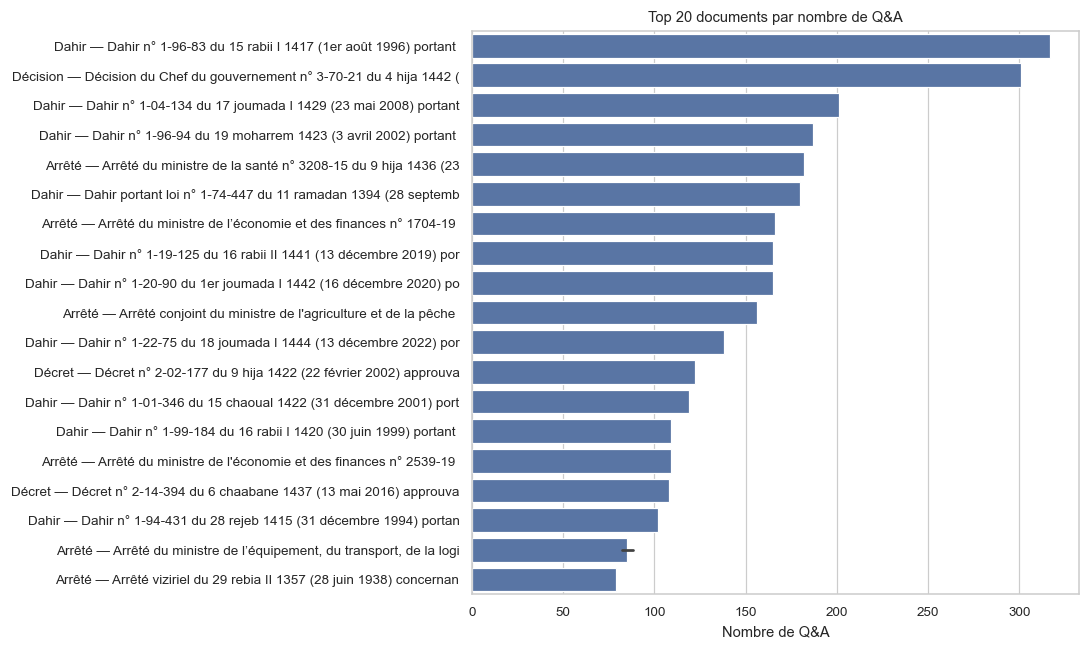

In [9]:
top_docs = qa.groupby('doc_id').agg(n=('qa_id','size'), title=('long_title','first'), typ=('doc_type','first')).nlargest(20, 'n')
top_docs['label'] = top_docs['typ'].fillna('') + ' — ' + top_docs['title'].fillna('').str.slice(0, 60)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(y=top_docs['label'], x=top_docs['n'], ax=ax, color='#4C72B0')
ax.set_title('Top 20 documents par nombre de Q&A')
ax.set_xlabel('Nombre de Q&A')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_top_docs_qa_count.png')
plt.show()

## Échantillons qualitatifs (3 × E/M/H × FR/AR)

In [10]:
def samples(lang, difficulty, n=3):
    sub = qa[(qa['lang'] == lang) & (qa['difficulty'] == difficulty)].sample(n=n, random_state=42)
    return sub[['qa_id', 'difficulty_score', 'doc_type', 'question', 'answer']].reset_index(drop=True)

for lang in ('fr', 'ar'):
    for diff in ('easy', 'medium', 'hard'):
        print(f'=== {lang.upper()} / {diff.upper()} ===')
        display(samples(lang, diff))

=== FR / EASY ===


,qa_id,difficulty_score,doc_type,question,answer
0,fr_12016,0.5146,Décret,Quelles sont les contraintes horaires de diffu...,Les programmes de fiction d'origine marocaine ...
1,fr_02798,0.5296,Dahir,Quel était le rôle de la commission prévue à l...,L'article 15 prévoit une commission composée d...
2,fr_07934,0.5311,Arrêté,Quelles sont les marques de jour spécifiques q...,"Selon la Règle 5 d), un navire remorqué dont l..."


=== FR / MEDIUM ===


,qa_id,difficulty_score,doc_type,question,answer
0,fr_11995,0.6037,Arrêté,Quelles sont les méthodes utilisées pour déter...,Selon l'article 3 de l'arrêté conjoint du 30 a...
1,fr_02854,0.6699,Décret,Quels sont les types de bâtiments en terre con...,Absolument ! Voici les informations concernant...
2,fr_08285,0.5490,Arrêté,Quelles sont les restrictions imposées à Air S...,L'arrêté impose plusieurs restrictions à Air S...


=== FR / HARD ===


...

,qa_id,difficulty_score,doc_type,question,answer
0,ar_01341,0.4101,Arrêté,ما هي الادوار والمسؤوليات الموكلة الي رؤساء ال...,لا يذكر في النص اي دور او مسؤولية محددة لرؤساء...
1,ar_04241,0.4555,Arrêté,ما هي اللغات الاجنبية التي يمكن للمرشحين دراست...,يمكن للمرشحين ان يختاروا دراسة احدي او اكثر من...
2,ar_02033,0.5030,Arrêté,ما هي مدة صلاحية طلب المنحة؟,مدة صلاحية طلب المنحة هي 12 شهرا من تاريخ انته...


=== AR / MEDIUM ===


,qa_id,difficulty_score,doc_type,question,answer
0,ar_01434,0.5711,Décret,ما هي الشروط التي بموجبها يمكن تعليق او سحب تر...,وفقا للمادة الثالثة من المرسوم رقم 2-04-684 بت...
1,ar_07144,0.5497,Dahir,كيف يتم تمثيل الدول الاعضاء في البرلمان الافريقي؟,تمثل الدول الاعضاء في البرلمان الافريقي بعدد م...
2,ar_02199,0.5142,Dahir,بالاضافة الي الرواتب الاساسية، ما هي الملحقات ...,بالاضافة الي الرواتب الاساسية، يتم اخذ جميع ال...


=== AR / HARD ===


,qa_id,difficulty_score,doc_type,question,answer
0,ar_01121,0.7337,Décret,ما هي انواع الضرائب والرسوم التي يتحملها المشت...,بالتاكيد، بناء علي النص المقدم، اليك انواع الض...
1,ar_04358,0.6585,Dahir,ما هي الاجراءات التي يجب علي غرفة التجارة والص...,بناء علي الوثيقة المقدمة، يجب علي غرفة التجارة...
2,ar_01817,0.6605,Dahir,هل يجب علي المهندس المعماري الاحتفاظ بدفتر الو...,نعم، يجب علي المهندس المعماري المكلف بادارة ال...


## Synthèse

| Métrique                       | FR           | AR           |
|-------------------------------|--------------|--------------|
| Q&A après préprocessing       | voir cellule 2 | voir cellule 2 |
| Seuil Easy (difficulty_score) | voir cellule 2 | voir cellule 2 |
| Seuil Medium                  | voir cellule 2 | voir cellule 2 |
| Contextes tronqués            | voir figure 4  | voir figure 4  |

**Sorties livrées aux équipes downstream :**
- `data/jurida_processed/` (HF DatasetDict, 12 splits)
- `data/interim/splits.json` (IDs par bucket + seuils + config_hash)
- `figures/fig1…fig8.png`

**Usage :**
```python
from datasets import load_from_disk
ds = load_from_disk('data/jurida_processed')
gp1_fr_train = ds['fr_easy_train']   # pour GP1 triage
s1_fr_hard_train = ds['fr_hard_train']  # pour spécialiste raisonnement
```